# Outros materiais de estudo

* [Datacamp](https://www.datacamp.com/pt/tutorial/decision-tree-classification-python)
* [Asimov](https://hub.asimov.academy/blog/arvores-de-decisao-em-python-estrutura-e-aplicacoes/)

# Explicação de uma Árvore de Decisão

Uma árvore de decisão é uma estrutura em forma de árvore parecida com um fluxograma, onde um nó interno representa uma característica (ou atributo), o ramo representa uma regra de decisão e cada nó folha representa o resultado.

O nó mais alto numa árvore de decisão é conhecido como nó raiz. Ele aprende a dividir com base no valor do atributo. Ele divide a árvore de um jeito recursivo, chamado particionamento recursivo. Essa estrutura tipo fluxograma te ajuda a tomar decisões. É uma visualização tipo um fluxograma que imita facilmente o pensamento humano. É por isso que as árvores de decisão são fáceis de entender e interpretar.

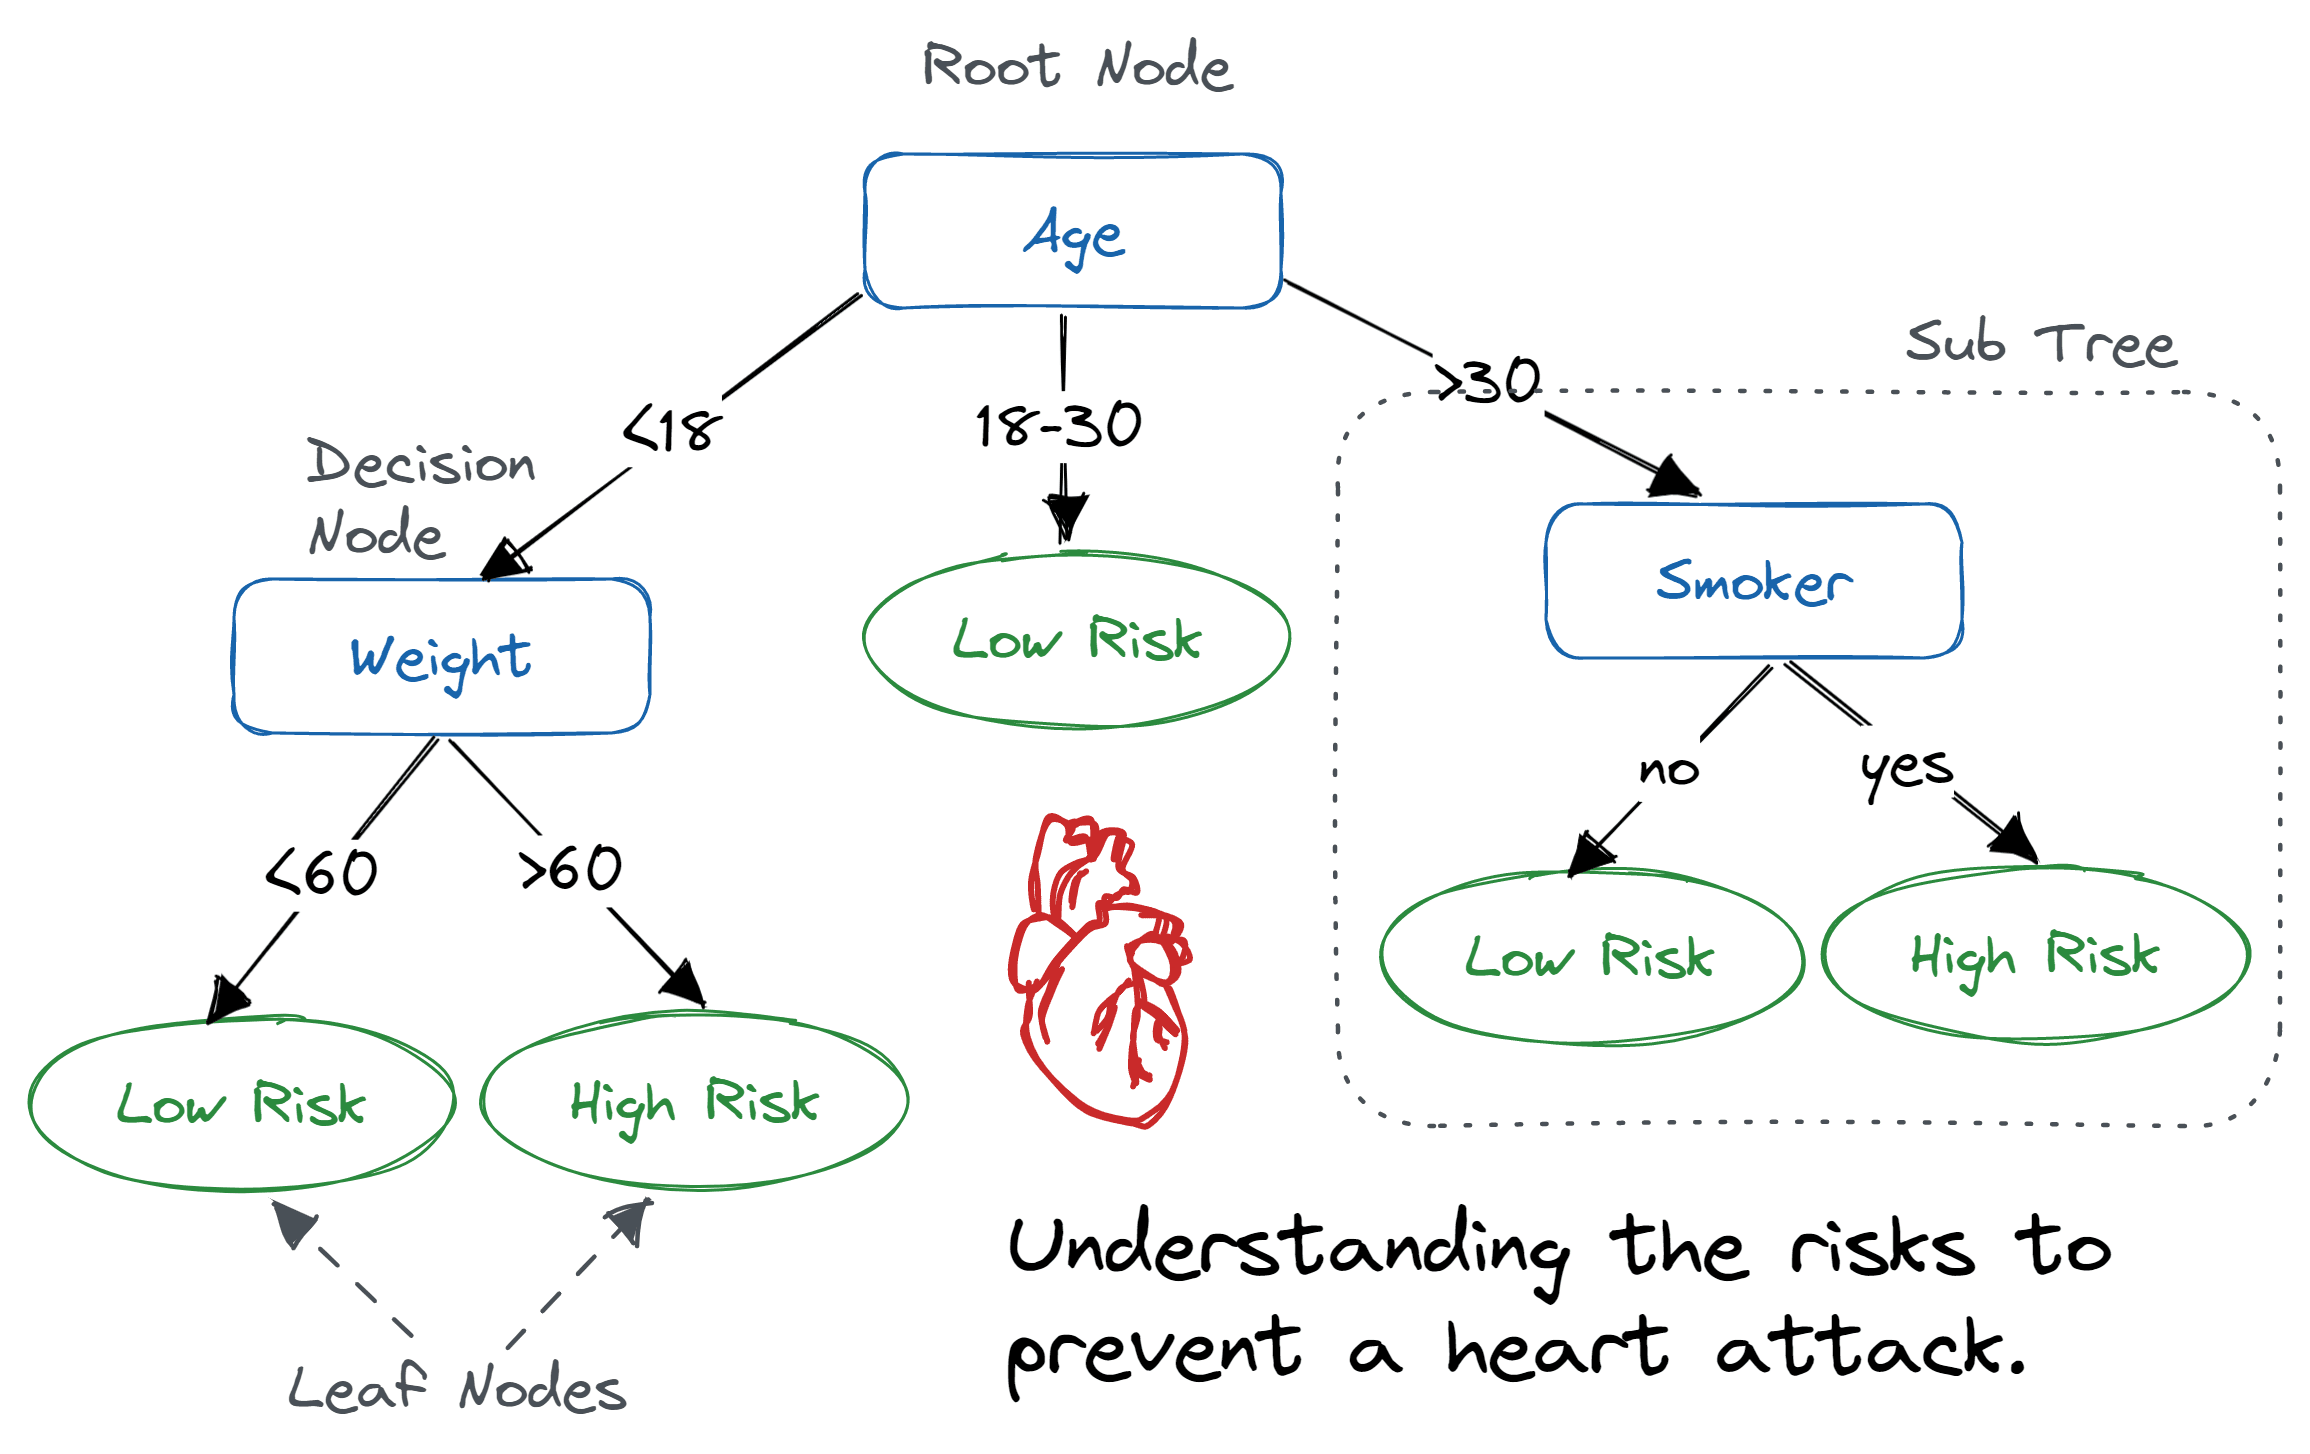

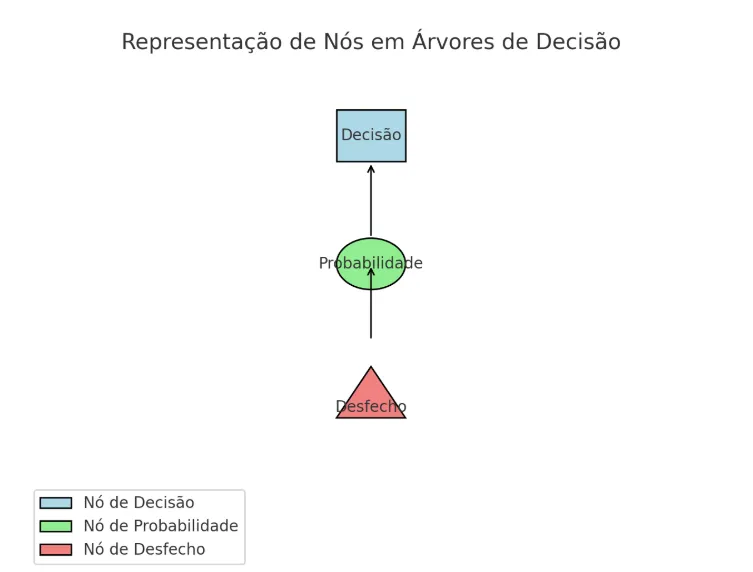

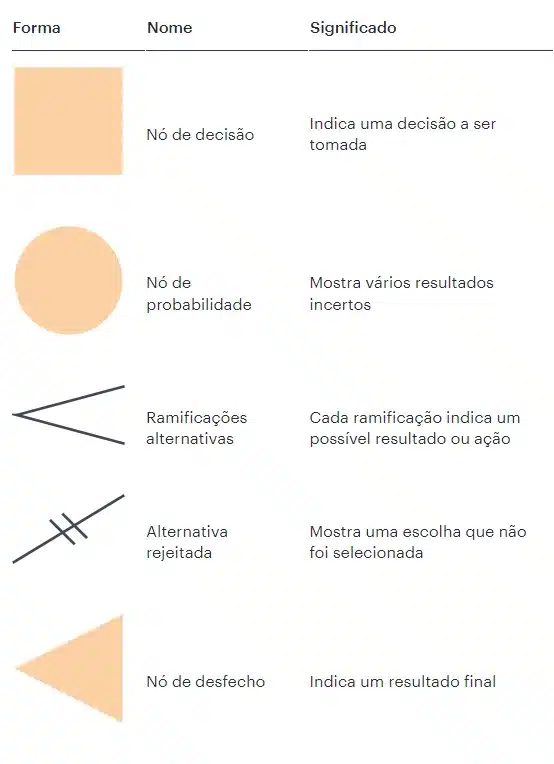

Uma árvore de decisão é um tipo de algoritmo de ML do tipo caixa branca.

* **Caixa branca:** compartilha a lógica interna de tomada de decisão. Que não está disponível em algoritmos do tipo caixa preta, como em uma rede neural.

O tempo de treinamento é mais rápido em comparação com o algoritmo de rede neural.

A complexidade temporal depende do número de registros e atributos nos dados fornecidos. A árvore de decisão é um método livre de distribuição ou não paramétrico que não depende de suposições sobre a distribuição de probabilidade subjacente dos dados (não se importa com o formato ou a distribuição dos dados). As árvores de decisão conseguem lidar com dados de alta dimensão com boa precisão (alta dimensão = tabelas de milhares de colunas).

# Desenvolvimento de uma Árvore de Decisão

Estudo após curso de KDD do [Moodle IFRS](https://moodle.ifrs.edu.br/course/view.php?id=10051). Certificado em 30 de Junho de 2026

Referência: [geekforgeeks](https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/)

**Aplicações**
* Utilizado em tarefas de classificação, como detecção de spam e de fraudes.
* Aplicado em problemas de regressão, como a previsão de preços de imóveis.
* Auxilia no diagnóstico médico e na previsão de doenças.
* Utilizado em análises de risco de crédito e sistemas de aprovação de empréstimos.
* Útil para seleção de atributos e segmentação de clientes.

**Vantagens**
* Fácil de entender, interpretar e visualizar.
* Funciona com dados tanto numéricos quanto categóricos.
* Requer pouco ou nenhum pré-processamento de dados.
* Não pressupõe nenhuma distribuição de dados específica.
* Fornece informações sobre a importância dos atributos para a interpretação do modelo.

**Limitações**
* Propenso ao *overfitting* (sobreajuste), especialmente com árvores profundas.
* Sensível a pequenas alterações nos dados de treinamento.
* Apresenta desempenho inferior em conjuntos de dados desbalanceados.
* Menor precisão em comparação com modelos de conjunto.
* Utiliza uma estratégia de divisão gulosa (*greedy*), que pode não ser globalmente ótima.

##Importações: Bibliotecas e Dependências

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

##Importar Dataset

In [ ]:
def importar_data():
  url = "https://archive.ics.uci.edu/static/public/12/data.csv" # Dataset do repositório UCI
  data_saldo = pd.read_csv(url, header=0)
  print("Dataset comprimento: " + str(len(data_saldo)) + "\n")
  print("Dataset formato: " + str(data_saldo.shape) + "\n")
  print("Dataset cabeçalho: \n" + str(data_saldo.head()) + "\n")
  return data_saldo

In [ ]:
importar_data()

Dataset comprimento: 625

Dataset formato: (625, 5)

Dataset cabeçalho: 
  class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5



,class,left-weight,left-distance,right-weight,right-distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5
...,...,...,...,...,...
620,L,5,5,5,1
621,L,5,5,5,2
622,L,5,5,5,3
623,L,5,5,5,4


##Separar o Dataset em Funcionalidades e Rótulos

In [ ]:
def separar_dataset(data_saldo):
  x = data_saldo.iloc[:, 1:5].values
  y = data_saldo.iloc[:, 0].values
  x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x, y, test_size=0.3,  random_state=100)
  return x, y, x_treinamento, x_teste, y_treinamento, y_teste

In [ ]:
# Saída
data_saldo = importar_data()
print("\n")
separar_dataset(data_saldo)

Dataset comprimento: 625

Dataset formato: (625, 5)

Dataset cabeçalho: 
  class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5





(array([[1, 1, 1, 1],
        [1, 1, 1, 2],
        [1, 1, 1, 3],
        ...,
        [5, 5, 5, 3],
        [5, 5, 5, 4],
        [5, 5, 5, 5]]),
 array(['B', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L',
        'B', 'R', 'R', 'R', 'B', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L', 'L',
        'B', 'R', 'R', 'L', 'R', 'R', 'R', 'R', 'B', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L', 'L', 'L',
        'B', 'R', 'L', 'B', 'R', 'R', 'R', 'L', 'R', 'R', 'R', 'R', 'B',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L', 'L', 'L', 'L',
        'B', 'L', 'L', 'R', 'R', 'R', 'L', 'R', 'R', 'R', 'R', 'L', 'R',
        'R', 'R', 'R', 'B', 'R', 'R', 'R', 'R', 'L', 'B', 'R', 'R', 'R',
        'B', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
        'R', 'R', 'R', 'R', 'R', 'R', 'R', 'L', 'L

##Treinar Árvore de Decisão usando Indexação Gini

In [ ]:
def treinar_usando_gini(x_treinamento, y_treinamento):
  clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
  clf_gini.fit(x_treinamento, y_treinamento)
  return clf_gini

##Treinar Árvore de Decisão usando Entropia

In [ ]:
def treinar_usando_entropia(x_treinamento, y_treinamento):
  clf_entropia = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
  clf_entropia.fit(x_treinamento, y_treinamento)
  return clf_entropia

##Fazer predições

In [ ]:
def predicao(x_treinamento, clf_predicao):
  y_predicao = clf_predicao.predict(x_treinamento)
  print("Valores preditos: \n", y_predicao)
  return y_predicao

##Avaliar precisão do modelo

In [ ]:
def calc_precisao(y_treinamento, y_predicao):
  print("Matrix de Confusão: \n" + str(confusion_matrix(y_treinamento, y_predicao)) + "\n")
  print("Acurácia: \n" + str(accuracy_score(y_treinamento, y_predicao) * 100) + "\n")
  print("Relatório de Classificação: \n", classification_report(y_treinamento, y_predicao))

##Visualizar Árvore de Decisão

In [ ]:
def montar_arvore_decisao(clf_objeto, nome_das_caracteristicas, nomes_das_classes):
  plt.figure(figsize=(15, 10))
  plot_tree(clf_objeto, filled=True, feature_names=nome_das_caracteristicas, class_names=nomes_das_classes, rounded=True)
  plt.show()

##Treinamento ▶ Predição ▶ Avaliação dos Modelos

In [ ]:
if __name__ == "__main__":
  dados = importar_data()
  x, y, x_treinamento, x_teste, y_treinamento, y_teste = separar_dataset(dados)

  print("\nTreinamento usando Indexação Gini: ")
  clf_gini = treinar_usando_gini(x_treinamento, y_treinamento)
  y_predicao_gini = predicao(x_teste, clf_gini)
  calc_precisao(y_teste, y_predicao_gini)

  print("\nTreinamento usando Entropia: ")
  clf_entropia = treinar_usando_entropia(x_treinamento, y_treinamento)
  y_predicao_entropia = predicao(x_teste, clf_entropia)
  calc_precisao(y_teste, y_predicao_entropia)

Dataset comprimento: 625

Dataset formato: (625, 5)

Dataset cabeçalho: 
  class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5


Treinamento usando Indexação Gini: 
Valores preditos: 
 ['R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L'
 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'L' 'R'
 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

A Árvore de Decisão treinada em Indexação Gini e Entropia alcançaram entre 73% a 71% de acurácia respectivamente, apresentando desempenho similar. Ambos os modelos classificaram as classes "**L**" e "**R**" razoávelmeente bem, mas falharam na predição correta para a classe "**B**", provavelmente devido a desproporção da classe.

##Montar as Árvores de Decisão

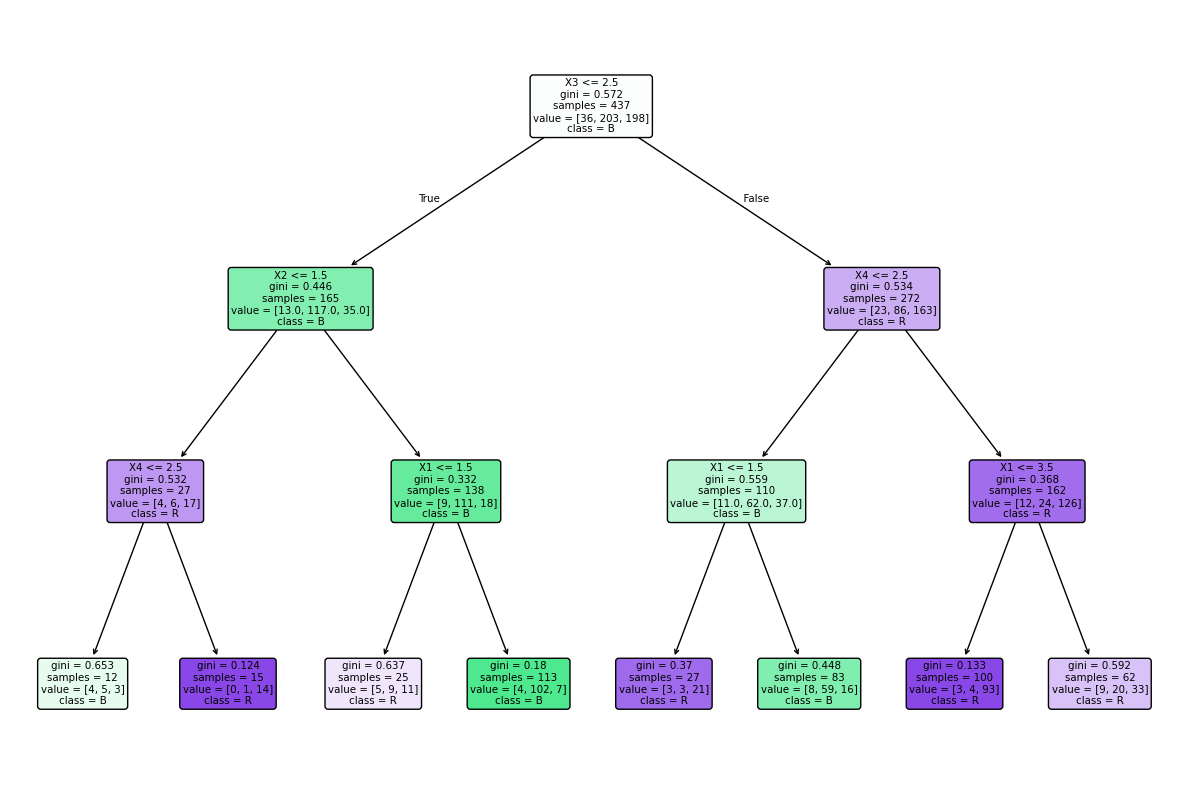

In [ ]:
montar_arvore_decisao(clf_gini, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])

A Árvode de Decisão realiza divisões com base na minimização da impureza de Gini, concentrando-se na frequência com que um elemento escolhido aleatoriamente seria classificado incorretamente. O objetivo é obter nós puros, com o mínimo de mistura de classes.

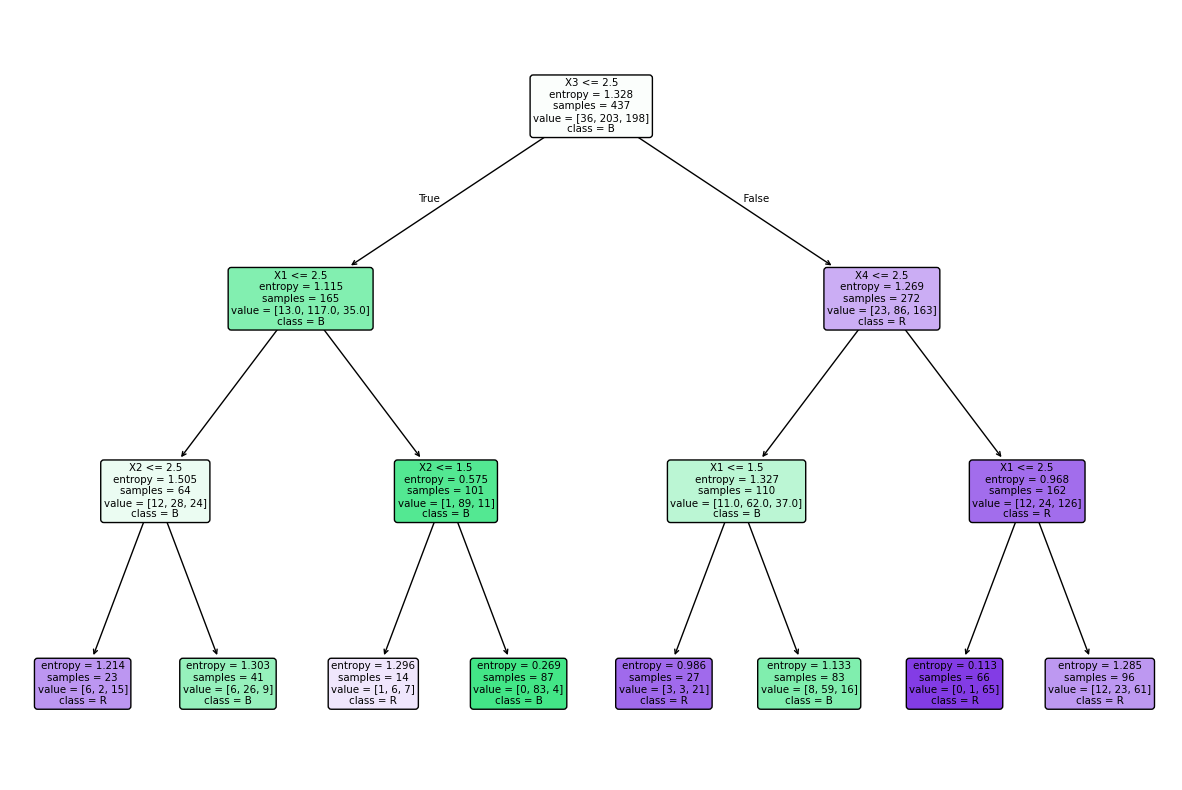

In [ ]:
montar_arvore_decisao(clf_entropia, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])

A Árvore de Decisão realiza divisões com base no ganho de informação (redução da entropia), selecionando divisões que maximizam a redução da incerteza sobre os rótulos de classe. Ela tende a criar divisões equilibradas que reduzem a desordem geral.

# Outro exemplo:

Exemplo seguido: [Datacamp](https://www.datacamp.com/pt/tutorial/decision-tree-classification-python)

Base de dados: [Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

##Importação de Bibliotecas e Dependências

In [ ]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

##Carregando os dados

In [ ]:
"""
Utilizando link direto do GitHub
"""

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# arquivo original pode vim sem o cabeçalho
nome_colunas = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, header=None, names=nome_colunas)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Seleção de recursos

Precisa dividir as colunas fornecidas em dois tipos de variáveis: variáveis dependentes (ou variáveis-alvo) e variáveis independentes (ou variáveis características).

In [ ]:
colunas_caracteristicas = ['Pregnancies', 'Insulin', 'BMI', 'Age', 'Glucose', 'BloodPressure','DiabetesPedigreeFunction']
x = df[colunas_caracteristicas] # Caracteristicas
y = df.Outcome # Variáveis alvo

#Dividindo dados

Dividir o conjunto de dados em um conjunto de treinamento e um conjunto de teste.

In [ ]:
"""
3 parâmetros:
 * Características;
 * Tamanho do conjunto de dados de destino;
 * Tamanho do conjunto de dados de teste
"""
# 70% treinamento - 30% teste
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x, y, test_size=0.3, random_state=1)

# Criando um modelo de Árvore de Decisão

In [ ]:
clf = DecisionTreeClassifier()

clf = clf.fit(x_treinamento, y_treinamento)

y_predicao = clf.predict(x_teste)

#Avaliando o modelo

A precisão pode ser calculada comparando os valores reais do conjunto de testes com os valores previstos.

In [ ]:
print("Acurácia: \n", metrics.accuracy_score(y_teste, y_predicao) * 100)

Acurácia: 
 67.53246753246754


#Visualizando Árvores de Decisão

##Por meio da "export_graphviz()"

Transforma o classificador da árvore de decisão em um arquivo dot, e o pydotplus transforma esse arquivo dot em PNG ou em um formato visivel no Jupyter

###Instalando dependências

In [ ]:
!pip install graphviz
!pip install pydotplus

### Importando Bibliotecas e Dependências

In [ ]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

### Montar a Árvore de Decisão

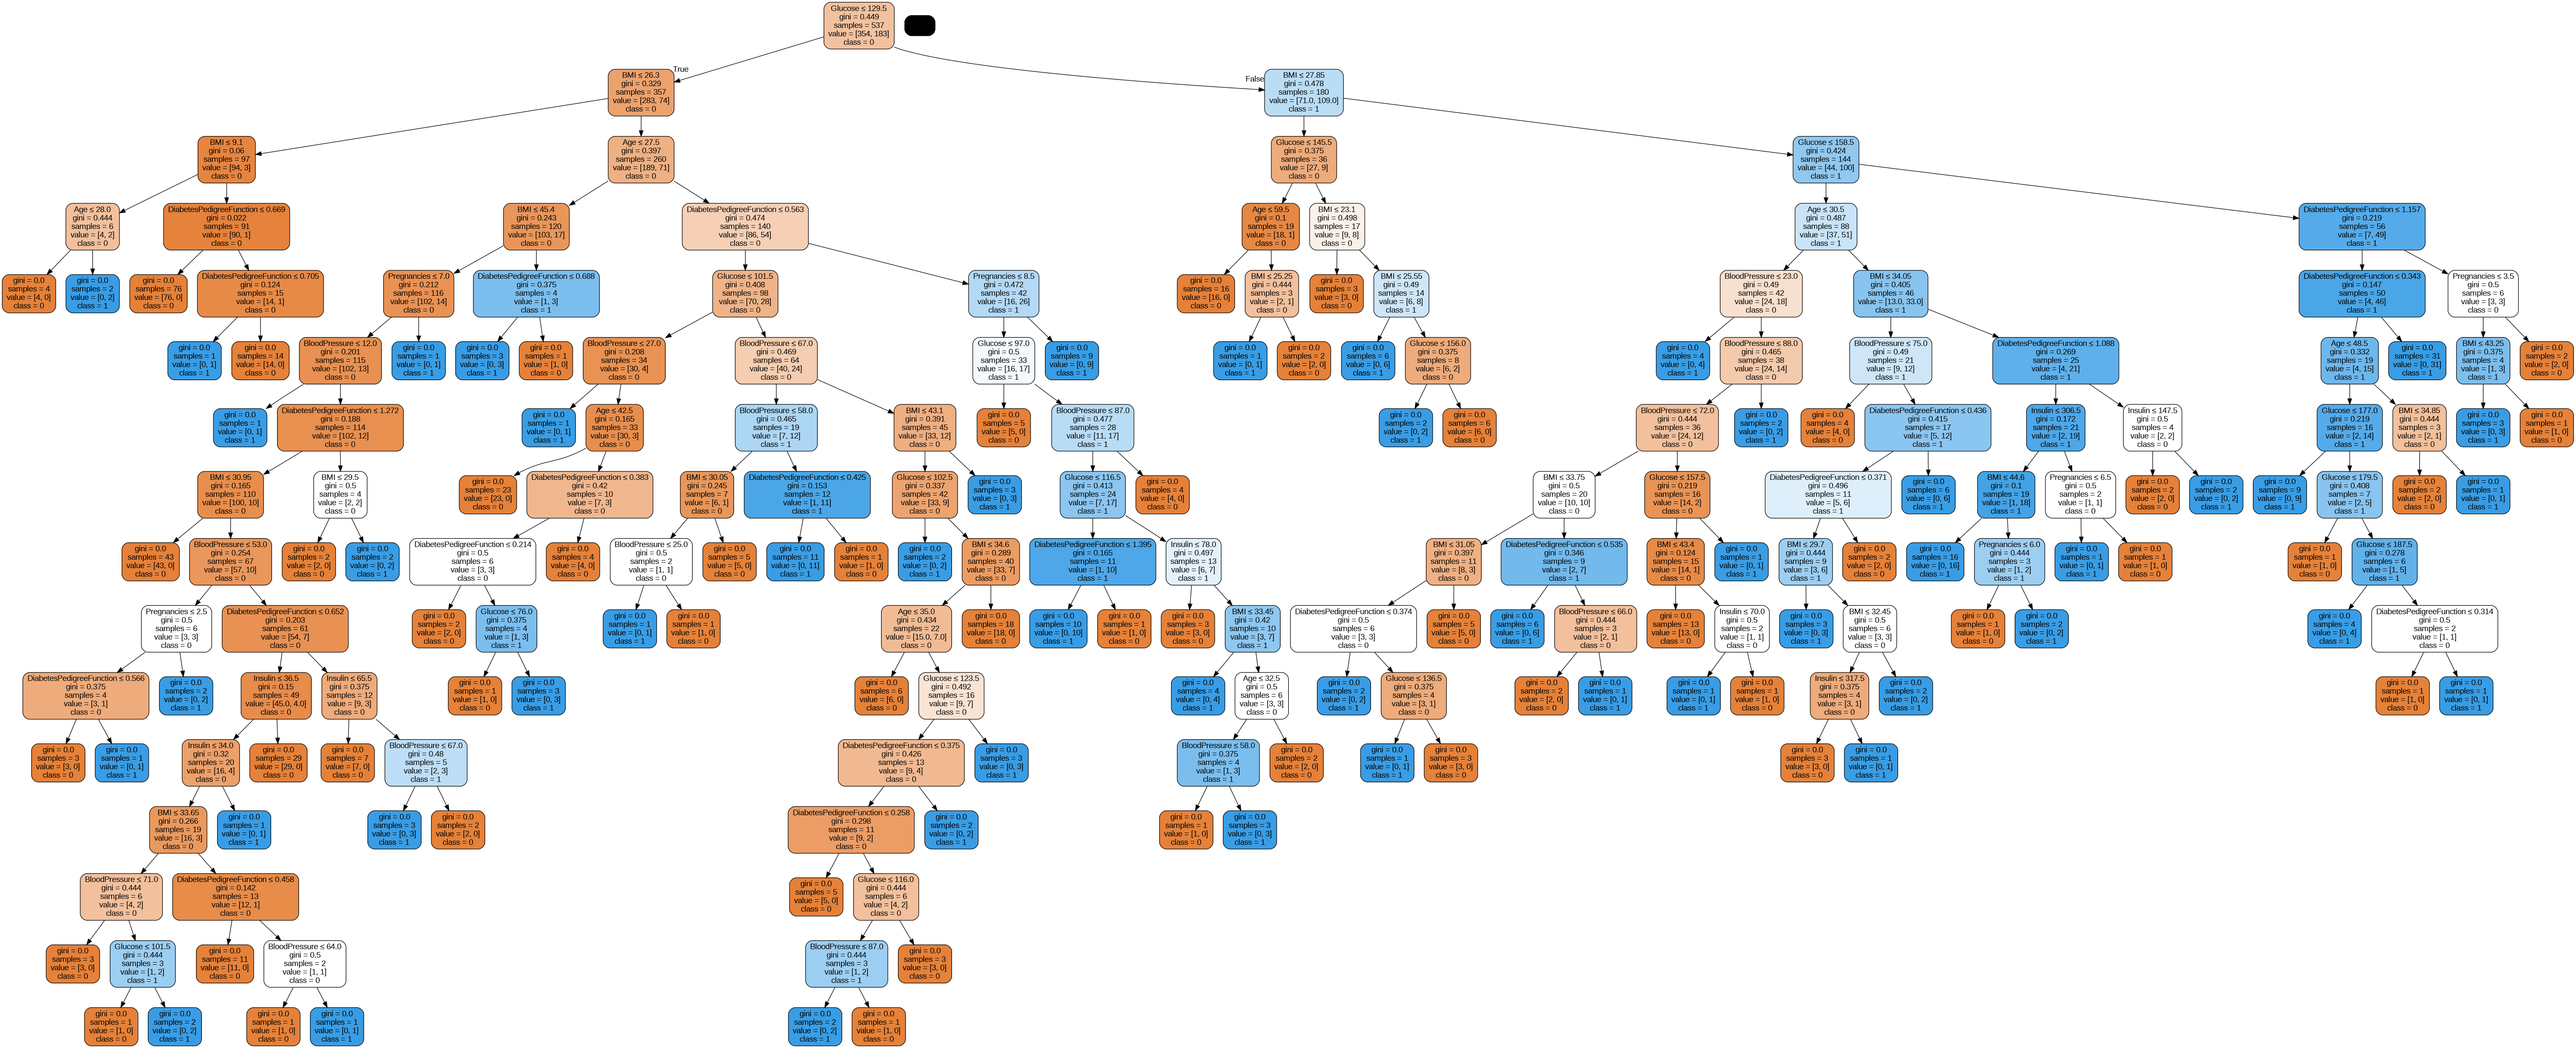

In [ ]:
dados_em_ponto = StringIO()
export_graphviz(clf, out_file=dados_em_ponto,
                filled=True, rounded=True,
                special_characters=True,feature_names = colunas_caracteristicas, class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dados_em_ponto.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

**ATENÇÃO**

A árvore resultante não foi podada. Essa árvore sem poda é inexplicável e difícil de entender. Na próxima seção, vamos otimizar isso com a poda.

## Otimizando o desemepnho da Árvore de Decisão (Realizando a Poda)

* **Critério:** opcional (padrão = “gini”) ou Escolha a medida de seleção de atributos.

    Esse parâmetro permite usar a medida de seleção de atributos diferentes-diferentes. Os critérios suportados são “gini” para o índice de Gini e “entropia” para o ganho de informação.

* **Divisor:** string, opcional (padrão = “melhor”) ou Estratégia de Divisão. Esse parâmetro permite escolher a estratégia de divisão.

    As estratégias suportadas são “melhor” para escolher a melhor divisão e “aleatória” para escolher a melhor divisão aleatória.

* **Max_depth:** int ou None, opcional (padrão=None) ou Profundidade máxima de uma árvore.

    A profundidade máxima da árvore. Se for None, os nós são expandidos até que todas as folhas tenham menos que min_samples_split amostras. Um valor mais alto de profundidade máxima faz com que o modelo se ajuste demais, e um valor mais baixo faz com que ele se ajuste de menos [Fonte](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [ ]:
# Scikit-learn, a otimização do classificador de árvore de decisão é feita apenas com pré-poda

clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf = clf.fit(x_treinamento,y_treinamento)

y_predicao = clf.predict(x_teste)

print("Acurácia: \n", metrics.accuracy_score(y_teste, y_predicao) * 100)

Acurácia: 
 77.05627705627705


##Melhorando a visualização da Árvore de Decisão

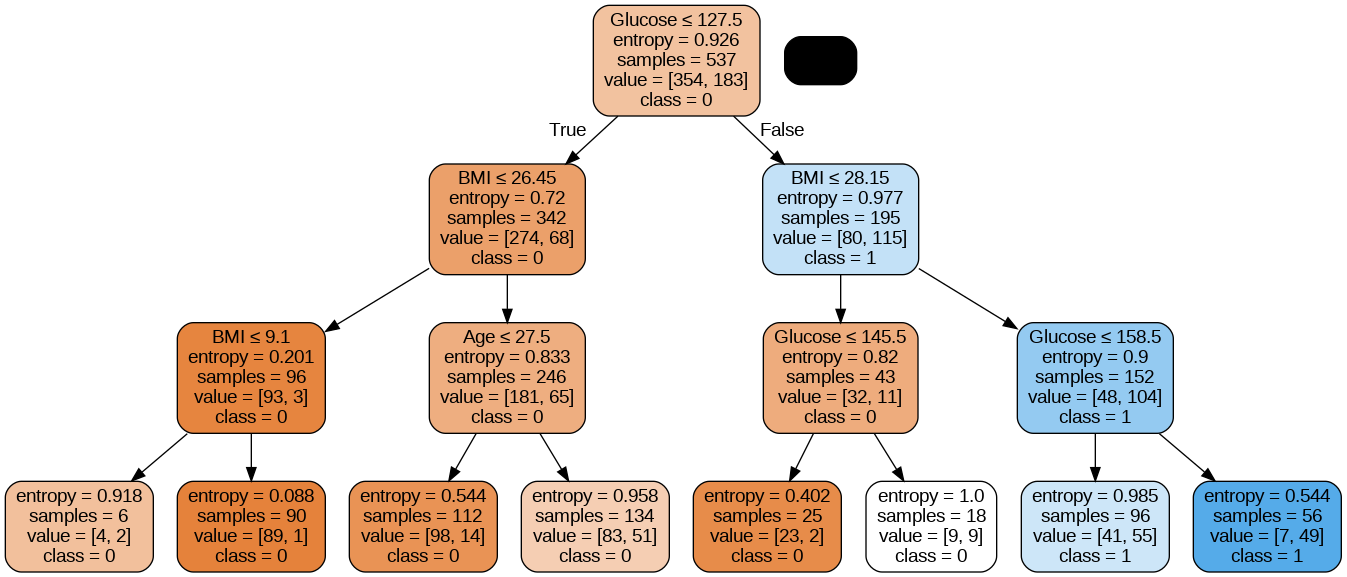

In [ ]:
dados_em_ponto = StringIO()
export_graphviz(clf, out_file=dados_em_ponto,
                filled=True,
                rounded=True,
                special_characters=True,
                feature_names=colunas_caracteristicas,
                class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dados_em_ponto.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())